# ArtExtract Task 1 - Full Tuned E8 Results

This notebook summarizes the final full-dataset run from `outputs/full_tuned_e8`.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

OUT = Path('../outputs/full_tuned_e8')
metrics = json.loads((OUT / 'val_metrics.json').read_text())
hist = json.loads((OUT / 'training_history.json').read_text())
metrics

{'style': {'accuracy_top1': 0.6233269598470363,
  'macro_precision': 0.3677733908742082,
  'macro_recall': 0.3499724054234531,
  'macro_f1': 0.3489133263826013,
  'weighted_f1': 0.6033269937505233,
  'balanced_accuracy': 0.3499724054234531},
 'artist': {'accuracy_top1': 0.5232632249840663,
  'macro_precision': 0.4838010955214084,
  'macro_recall': 0.4922035992135204,
  'macro_f1': 0.47292502745241644,
  'weighted_f1': 0.5054354954413274,
  'balanced_accuracy': 0.4922035992135204},
 'genre': {'accuracy_top1': 0.6080305927342257,
  'macro_precision': 0.49308354813833377,
  'macro_recall': 0.4722671109396708,
  'macro_f1': 0.468773324078722,
  'weighted_f1': 0.5927981694523236,
  'balanced_accuracy': 0.4722671109396708},
 'artist_top5': 0.8538347142553644,
 'samples_val': 4707}

In [2]:
summary = pd.DataFrame([
    {'task':'style','top1':metrics['style']['accuracy_top1'],'macro_f1':metrics['style']['macro_f1']},
    {'task':'artist','top1':metrics['artist']['accuracy_top1'],'top5':metrics['artist_top5'],'macro_f1':metrics['artist']['macro_f1']},
    {'task':'genre','top1':metrics['genre']['accuracy_top1'],'macro_f1':metrics['genre']['macro_f1']},
])
summary

,task,top1,macro_f1,top5
0,style,0.623327,0.348913,NaN
1,artist,0.523263,0.472925,0.853835
2,genre,0.608031,0.468773,NaN


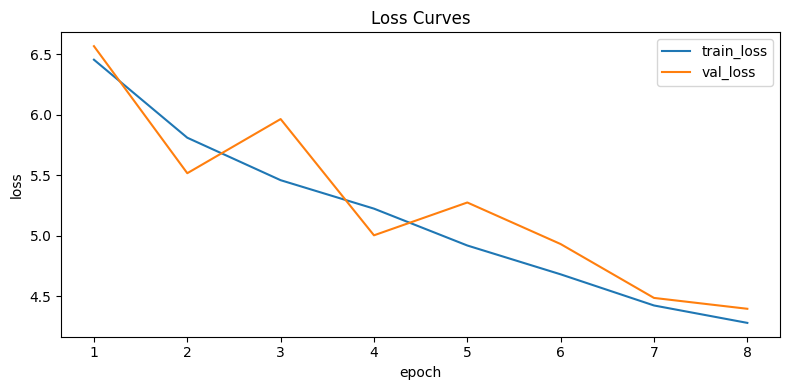

In [3]:
epochs = [r['epoch'] for r in hist]
plt.figure(figsize=(8,4))
plt.plot(epochs, [r['train_loss'] for r in hist], label='train_loss')
plt.plot(epochs, [r['val_loss'] for r in hist], label='val_loss')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.title('Loss Curves'); plt.legend(); plt.tight_layout()
plt.show()

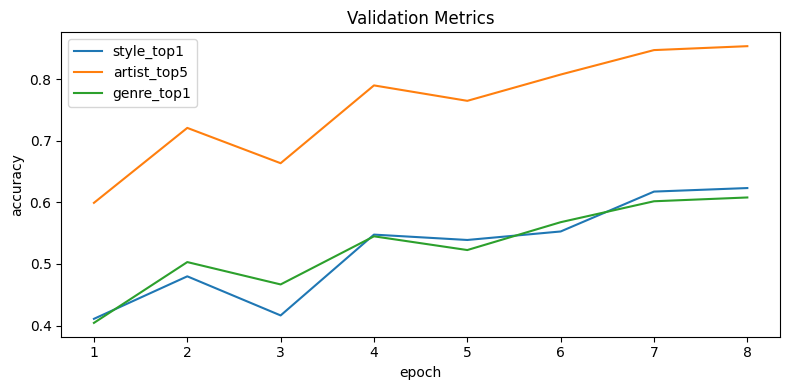

In [4]:
plt.figure(figsize=(8,4))
plt.plot(epochs, [r['val_style_top1'] for r in hist], label='style_top1')
plt.plot(epochs, [r['val_artist_top5'] for r in hist], label='artist_top5')
plt.plot(epochs, [r['val_genre_top1'] for r in hist], label='genre_top1')
plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.title('Validation Metrics'); plt.legend(); plt.tight_layout()
plt.show()

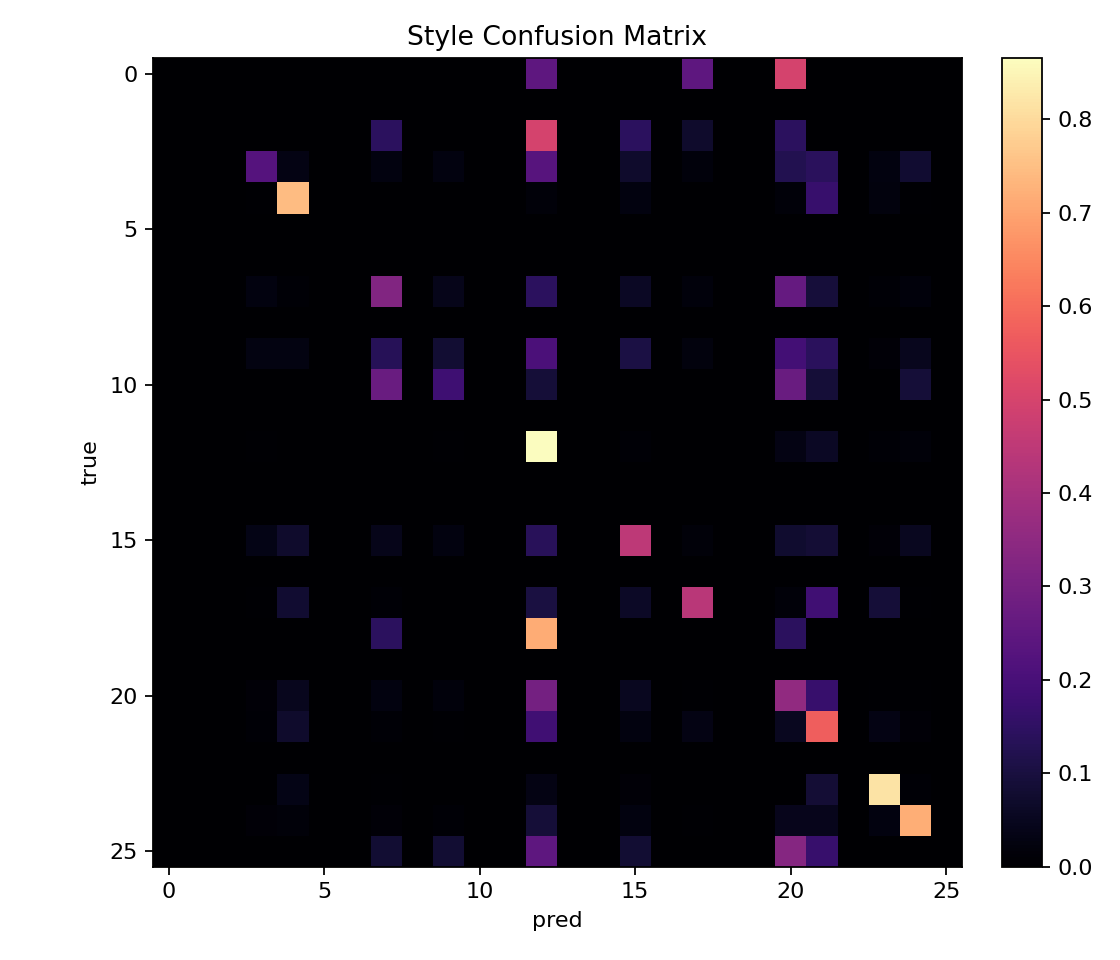

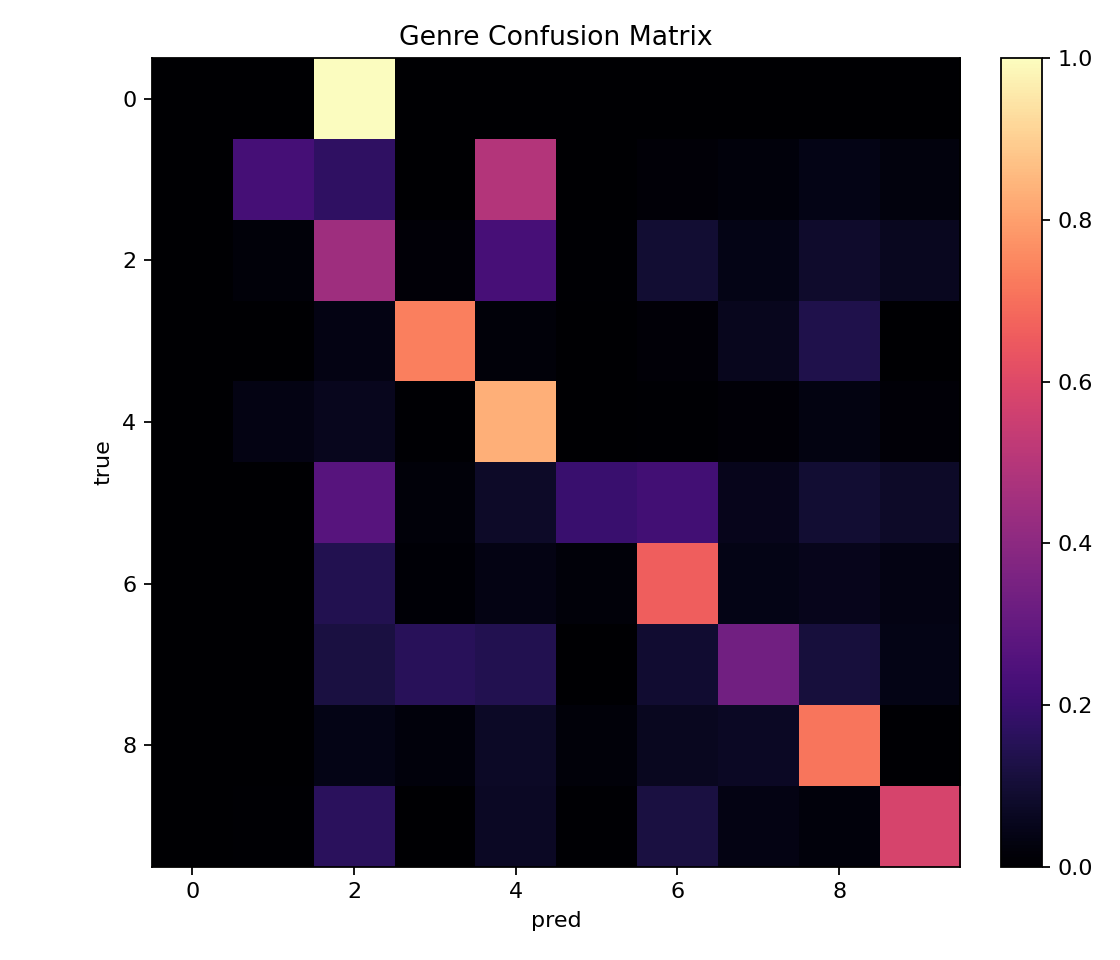

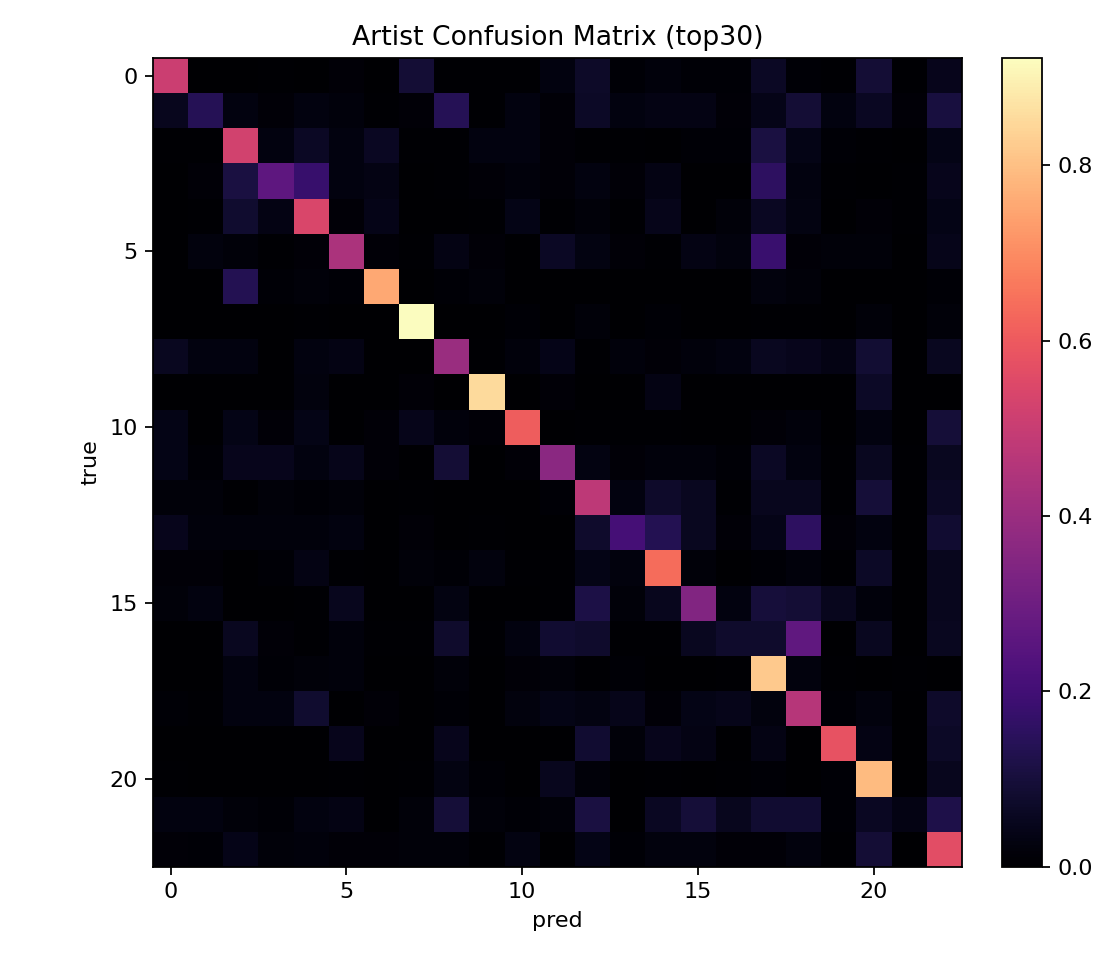

In [5]:
from IPython.display import Image, display
display(Image(filename=str(OUT / 'style_confusion_matrix.png')))
display(Image(filename=str(OUT / 'genre_confusion_matrix.png')))
display(Image(filename=str(OUT / 'artist_confusion_matrix_top30.png')))

In [6]:
outliers = pd.read_csv(OUT / 'style_outliers.csv')
outliers.head(20)

,index,class_id,score
0,629,12,5.067897
1,3541,24,4.859658
2,1726,21,4.349294
3,141,12,4.111395
4,1645,21,4.095620
5,2381,21,4.027822
6,1435,12,3.963147
7,331,12,3.962360
8,3317,20,3.820931
9,1882,21,3.723417
